# Assignment 14: Random Forest Classifier
##### Author: Md Ashhar Farooqui
##### Date: 22-07-2025

In [11]:
# Importing all the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score 

In [12]:
df = pd.read_excel("glass.xlsx", sheet_name="glass")
# Display the first few rows of the dataset
df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


# 1. Exploratory Data Analysis (EDA):

In [13]:
# Finding the number of missing values in each column
missing_values = df.isnull().sum()
print("Missing values in each column:")
print(missing_values)

Missing values in each column:
RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64


In [14]:
# Finding duplicate rows in the dataset
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

Number of duplicate rows: 1


In [15]:
# Dropping duplicate rows
df.drop_duplicates(inplace=True)    
# Displaying the shape of the dataset after dropping duplicates
print(f"Shape of the dataset after dropping duplicates: {df.shape}")

Shape of the dataset after dropping duplicates: (213, 10)


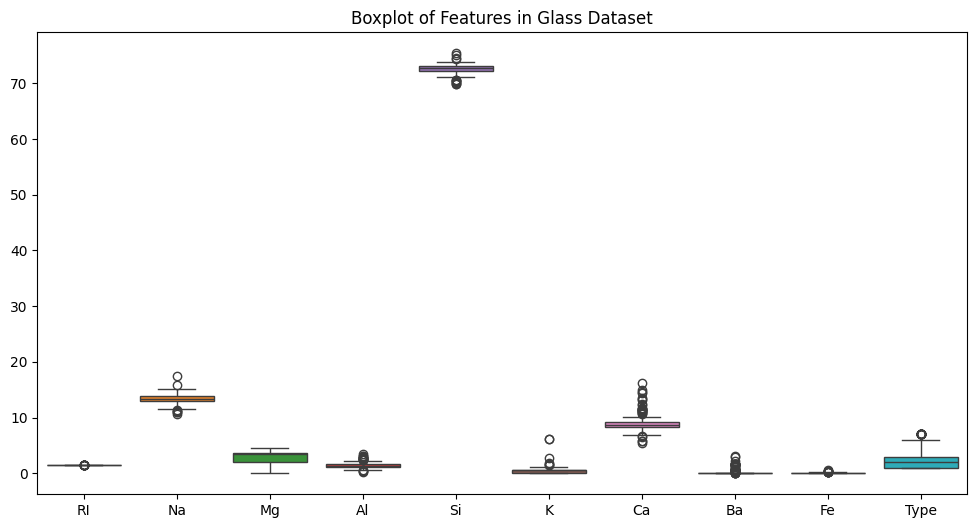

In [16]:
# Checking the outliers in the dataset
plt.figure(figsize=(12, 6))
sns.boxplot(data=df)
plt.title("Boxplot of Features in Glass Dataset")
plt.show()

In [17]:
# Checking inconsistent data types in the dataset
print("Data types of each column:")
print(df.dtypes)

Data types of each column:
RI      float64
Na      float64
Mg      float64
Al      float64
Si      float64
K       float64
Ca      float64
Ba      float64
Fe      float64
Type      int64
dtype: object


In [18]:
# Converting the 'Type' column to categorical type
df['Type'] = df['Type'].astype('category')
# Displaying the data types after conversion
print("Data types after conversion:")
print(df.dtypes)

Data types after conversion:
RI       float64
Na       float64
Mg       float64
Al       float64
Si       float64
K        float64
Ca       float64
Ba       float64
Fe       float64
Type    category
dtype: object


# 2: Data Visualization:

Create visualizations such as histograms, box plots, or pair plots to visualize the distributions and relationships between features.
Analyze any patterns or correlations observed in the data.

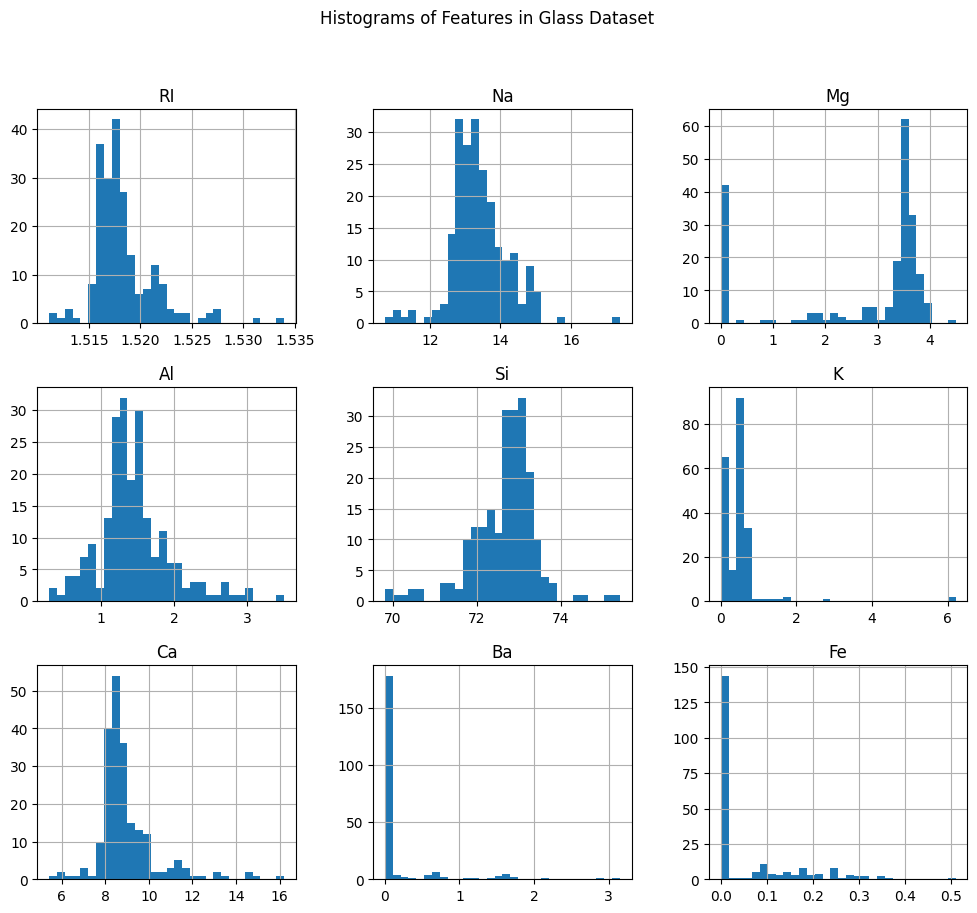

In [21]:
# Visualizing histograms for each feature
df.hist(figsize=(12, 10), bins=30)
plt.suptitle("Histograms of Features in Glass Dataset")
plt.show()

<Figure size 1200x600 with 0 Axes>

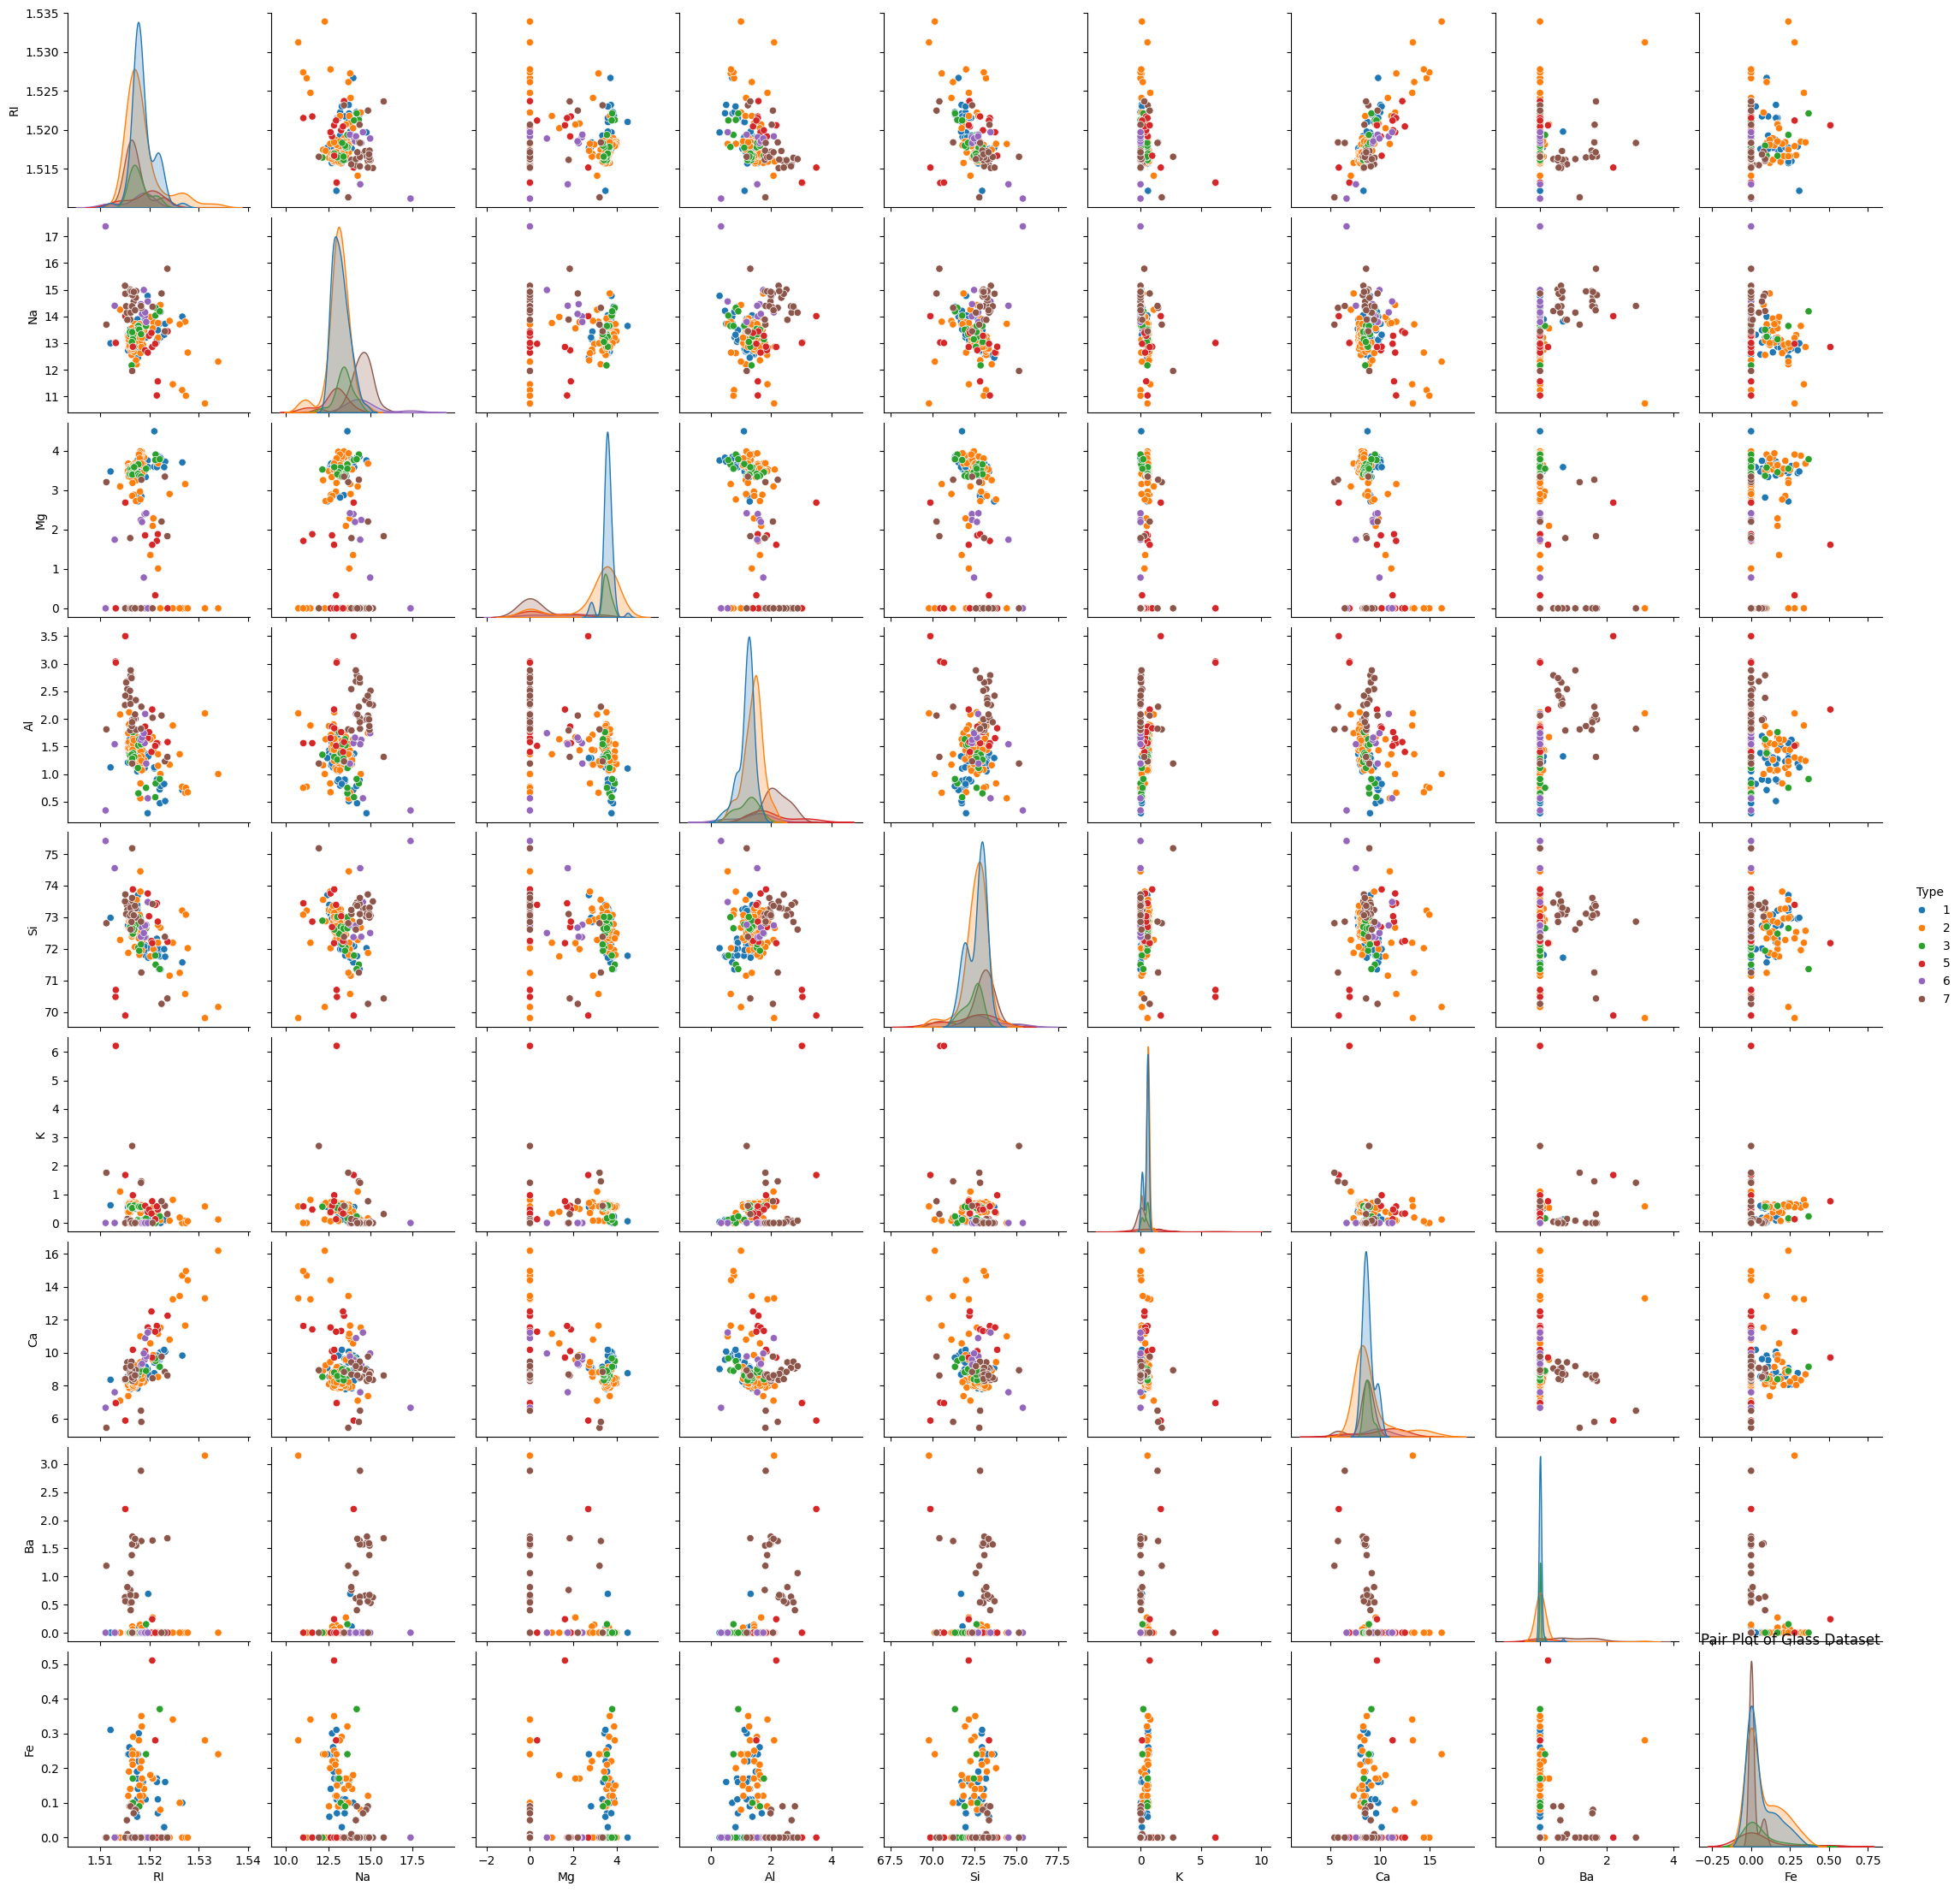

In [19]:
# Creating visualizations such as histograms, box plots, or pair plots to visualize the distributions and relationships between features
plt.figure(figsize=(12, 6))
sns.pairplot(df, hue='Type')
plt.title("Pair Plot of Glass Dataset")
plt.show()

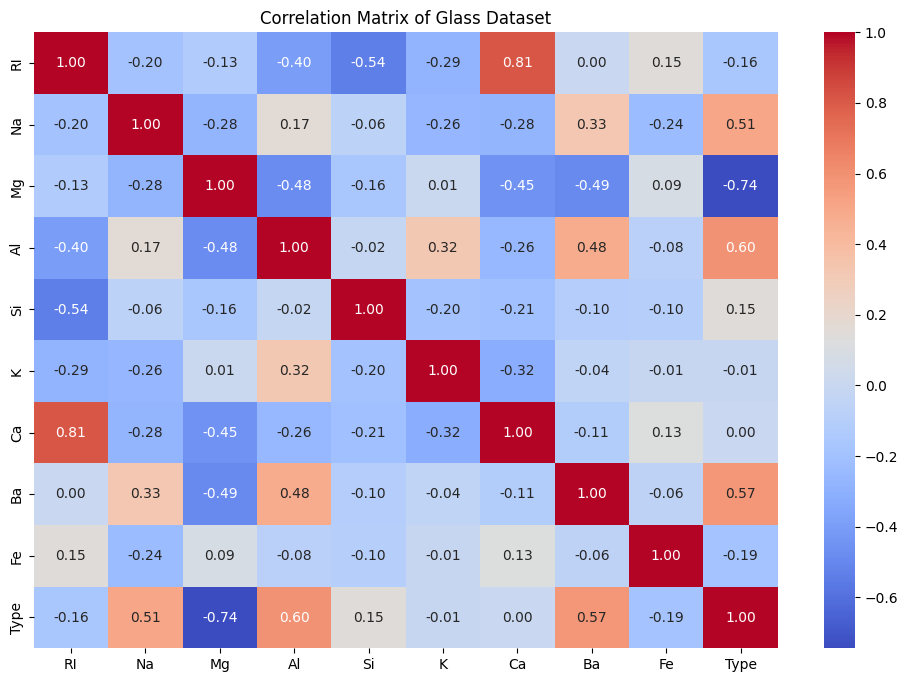

In [20]:
# Analyzing any patterns or correlations observed in the data
correlation_matrix = df.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix of Glass Dataset")
plt.show()

# 3: Data Preprocessing

1. Check for missing values in the dataset and decide on a strategy for handling them.Implement the chosen strategy (e.g., imputation or removal) and explain your reasoning.
2. If there are categorical variables, apply encoding techniques like one-hot encoding to convert them into numerical format.
3. Apply feature scaling techniques such as standardization or normalization to ensure that all features are on a similar scale. Handling the imbalance data.


In [23]:
# 3.1 Handling missing values
print("Missing values before removal:")
print(df.isnull().sum())

Missing values before removal:
RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64


In [24]:
# Remove rows with missing values (since there are many empty rows at the end of your CSV)
df = df.dropna()
print("Shape after removing missing values:", df.shape)

Shape after removing missing values: (213, 10)


In [25]:
# 3.3 Feature scaling (Standardization)
from sklearn.preprocessing import StandardScaler

X = df.drop('Type', axis=1)
y = df['Type']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4: Random Forest Model Implementation
1. Divide the data into train and test split.
2. Implement a Random Forest classifier using Python and a machine learning library like scikit-learn.
3. Train the model on the train dataset. Evaluate the performance on test data using metrics like accuracy, precision, recall, and F1-score.


In [26]:
# 4.1 Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

In [27]:

# 4.2 Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [28]:
# 4.3 Evaluation
y_pred = rf.predict(X_test)
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.8372093023255814
Classification Report:
               precision    recall  f1-score   support

           1       0.81      0.93      0.87        14
           2       0.85      0.73      0.79        15
           3       1.00      0.67      0.80         3
           5       0.67      0.67      0.67         3
           6       0.67      1.00      0.80         2
           7       1.00      1.00      1.00         6

    accuracy                           0.84        43
   macro avg       0.83      0.83      0.82        43
weighted avg       0.85      0.84      0.84        43

Confusion Matrix:
 [[13  1  0  0  0  0]
 [ 2 11  0  1  1  0]
 [ 1  0  2  0  0  0]
 [ 0  1  0  2  0  0]
 [ 0  0  0  0  2  0]
 [ 0  0  0  0  0  6]]


# 5: Bagging and Boosting Methods
Apply the Bagging and Boosting methods and compare the results.


In [30]:
# 5.1 Bagging
from sklearn.ensemble import BaggingClassifier

bagging = BaggingClassifier(estimator=RandomForestClassifier(), n_estimators=50, random_state=42)
bagging.fit(X_train, y_train)
y_pred_bag = bagging.predict(X_test)
print("Bagging Accuracy:", accuracy_score(y_test, y_pred_bag))

Bagging Accuracy: 0.7906976744186046


In [31]:

# 5.2 Boosting (using AdaBoost)
from sklearn.ensemble import AdaBoostClassifier

boosting = AdaBoostClassifier(n_estimators=50, random_state=42)
boosting.fit(X_train, y_train)
y_pred_boost = boosting.predict(X_test)
print("Boosting Accuracy:", accuracy_score(y_test, y_pred_boost))

Boosting Accuracy: 0.4418604651162791


# Additional Notes:
1. Explain Bagging and Boosting methods. How is it different from each other.

Bagging vs Boosting:

- Bagging (Bootstrap Aggregating) trains multiple models independently on random subsets of the data and averages their predictions. It reduces variance and helps prevent overfitting.
- Boosting trains models sequentially, each focusing on correcting the errors of the previous one. It reduces bias and can improve accuracy but may be more prone to overfitting.

2. Explain how to handle imbalance in the data.

Handling Imbalanced Data:

- Use techniques like stratified sampling, resampling (oversampling minority or undersampling majority classes), or use class weights in your classifier (e.g., class_weight='balanced' in scikit-learn).